# "Alphabet-level activities" compute model

A Monte Carlo estimate of how much compute is implied by Alphabet's
**"Alphabet-level activities"** expense line, expressed in H100-equivalents
(H100e).

**Background.** Alphabet reports an operating-expense line it describes as
"primarily reflecting expenses related to our shared AI research and
development." In substance this is where most of DeepMind's R&D cost lands,
because Gemini models are a shared input to every Google segment and can't be
cleanly allocated to one. The bucket was **$16.76B in 2025** ($10.5B in 2024,
$9.19B in 2023) and **$5.39B in Q1 2026** (~$21.6B annualized).

But the line item mixes several things. Alphabet says it contains:

1. shared AI R&D — **employee compensation** *and* **technical infrastructure
   usage costs** (i.e. compute);
2. corporate initiatives such as **philanthropy**;
3. corporate shared costs — certain **finance, HR, and legal** costs,
   including **fines and settlements**.

So the dollar figure is only a *rough upper bound* on DeepMind's R&D compute
spend. Two things stand between the headline number and an H100e count, and
they are the two uncertainties this model samples:

- **What share of the bucket is compute** (vs. salaries, philanthropy, legal)?
- **How expensive is an internal H100e-hour on Google's books?** DeepMind runs
  mostly on Google-owned TPUs, so Google is selling compute to itself. It
  almost certainly books this at *cost* (depreciation + amortization + operating
  expenses), **not** at a market GPU-hour rate with a profit margin — and TPUs
  are cheaper per FLOP than Nvidia. We anchor this to SemiAnalysis's TCO
  comparison. That makes these dollars buy *more* H100e-hours than the same
  dollars would at OpenAI or Anthropic, who rent at market rates.

**Method.** For a given period,

> `avg H100e used = (spend × compute_share) ÷ internal_$_per_H100e_hour ÷ hours_in_period`

The result is the **average number of H100e running continuously** over the
period to consume that much compute budget. It covers R&D/training only —
product inference is booked in the business segments, not here.

**All sampled inputs are lognormal.** Each low/high pair is read as the **90%
credible interval** (5th–95th percentile).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import B

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions/prices and shown as decimals;
    larger values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Canonical parameters

The sampled priors are loaded from `lab_model_params.csv` (lab
`alphabet_activities`) — the shared source of truth for the lab compute
models. Edit the sheet (leaving a note in its description column) to change
a prior. The two share parameters are clipped at 1 so no sample implies more
than 100% of a whole.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["alphabet_activities"]
lab_params_table("alphabet_activities")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,compute_share,to,0.3,0.70,NaN,1.0,share,Share of the Alphabet-level activities expense...,2026-07-02
1,nvidia_market_price,to,1.5,2.00,NaN,NaN,USD/H100e-hr,"Market price to rent one H100e (Hopper anchor,...",2026-07-02
2,cloud_margin,to,0.2,0.45,NaN,NaN,share,Cloud gross margin stripped from the market pr...,2026-07-02
3,tpu_vs_nvidia_tco,to,0.5,0.78,NaN,NaN,ratio,TPU vs Nvidia TCO per marketed 8-bit PFLOP (Se...,2026-07-02
4,tpu_share,to,0.7,0.90,NaN,1.0,share,TPU share of the DeepMind fleet cost blend; cl...,2026-07-02


## Known inputs: the reported spend

These come straight from Alphabet's filings, so we treat them as fixed rather
than sampling them. We run the model for two periods:

- **Q1 2026** — the most recent data point ($5.39B per the 10-Q), giving the
  freshest snapshot.
- **Full-year 2025** ($16.76B) — for comparison / an annual average.

The number of hours in the period is what turns a pile of compute-dollars into
an *average concurrent* chip count.

In [3]:
spend_q1_2026 = 5.391 * B    # Alphabet-level activities, Q1 2026 (10-Q: $5,391M)
spend_fy_2025 = 16.76 * B    # Alphabet-level activities, full-year 2025

# Hours in each period. Q1 = Jan+Feb+Mar = 90 days; a full year = 8760 hours.
hours_q1_2026 = 90 * 24      # 2160
hours_fy_2025 = 8760

print(f"Q1 2026 spend: ${spend_q1_2026/1e9:.1f}B over {hours_q1_2026} hours")
print(f"FY 2025 spend: ${spend_fy_2025/1e9:.2f}B over {hours_fy_2025} hours")

Q1 2026 spend: $5.4B over 2160 hours
FY 2025 spend: $16.76B over 8760 hours


## Uncertainty 1: what share of the bucket is compute?

The bucket is predominantly AI R&D (Alphabet added a one-line summary in 2025
emphasizing this), and within AI R&D the two ingredients are employee
compensation and "technical infrastructure usage costs" (compute). The rest is
corporate overhead — philanthropy, finance/HR/legal, and lumpy fines and
settlements.

Rough sizing of the *non-compute* pieces against a ~$17–21B annualized bucket:

- **DeepMind compensation:** on the order of a few thousand researchers/engineers
  at fully-loaded costs of several hundred $k each ⇒ very roughly $3–4B/yr.
- **Overhead** (philanthropy + shared finance/HR/legal + settlements): another
  few $B/yr, and *lumpy* — a large settlement in one period can swing this.

That leaves compute as somewhere around **a third to two-thirds** of the total,
with wide uncertainty. We use a 90% CI of **0.30–0.70** (lognormal, median ~0.46).
This deliberately doesn't try to strip out the further wrinkles that some
DeepMind R&D may be booked in a product segment instead, or that some compute
here isn't strictly frontier R&D — those are discussed as caveats below.

In [4]:
compute_share = PARAMS["compute_share"]
compute_share_samples = compute_share @ N_SAMPLES
summary("Compute share of Alphabet-level activities", compute_share_samples);

Compute share of Alphabet-level activities
  90% CI : 0.297 – 0.695
  median : 0.458
  mean   : 0.471


## Uncertainty 2: the internal cost of an H100e-hour

This is the crux, and the reason Alphabet-level dollars are *apples-to-oranges*
with OpenAI's or Anthropic's cloud bills. Google runs DeepMind mostly on its own
TPUs and bills the cost internally — depreciation + amortization + operating
expenses — with **no cloud profit margin**. Google's self-built TPUs are also
cheaper per FLOP than renting Nvidia. We build the cost up in four steps,
anchored to SemiAnalysis's TCO comparison
([TPU v7 analysis](https://newsletter.semianalysis.com/p/tpuv7-google-takes-a-swing-at-the)).

**Step 1 — base: external Nvidia cloud price.** Market rate to rent one H100e
(Hopper, 3-year contract) is about **$1.50–2.00/GPU-hr**. This is a *price*: it
includes the cloud provider's margin.

**Step 2 — strip the cloud margin.** Google bills DeepMind at cost, so we remove
the gross margin a cloud would charge. AI cloud margins are perhaps **20–45%**
(the low-30s is a common estimate; SemiAnalysis's TCO figures imply the higher
end). Nvidia internal cost = price × (1 − margin).

**Step 3 — TPU vs Nvidia cost advantage (from SemiAnalysis).** On a *TCO per
marketed 8-bit PFLOP* basis — the right normalization for H100e — SemiAnalysis
puts TPU v7 (internal) at **$0.28** vs Nvidia GB200 at **$0.46** and GB300 at
**$0.55**. So a TPU delivers the same FP8 throughput at roughly **0.51–0.76×**
Nvidia's cost (central ~0.61). Generalizing "TPU v7 : GB200" to "TPU : Nvidia
fleet-wide," we take **0.50–0.78**. TPU internal cost = Nvidia internal cost ×
this ratio.

**Step 4 — blend by fleet mix.** DeepMind's fleet is TPU-heavy but part is
Nvidia (Google overall is ~¾ TPU by H100e; DeepMind likely at least that
TPU-weighted). We take the **TPU share at 0.70–0.90** and blend the two costs.

The result lands around **$0.8/H100e-hr** — above the naive bottom-up (~$0.67)
used previously, and closer to the level needed to reconcile with the top-down
DeepMind model. As a cross-check, converting SemiAnalysis's TCO directly gives
TPU-v7-internal ≈ $0.55/H100e-hr and GB200 ≈ $0.91/H100e-hr.

In [5]:
# Step 1: external Nvidia cloud market price for one H100e-hour (Hopper anchor).
nvidia_market_price = PARAMS["nvidia_market_price"] @ N_SAMPLES

# Step 2: strip the cloud gross margin to get Nvidia cost-basis on Google's books.
cloud_margin = PARAMS["cloud_margin"] @ N_SAMPLES
nvidia_internal_cost = nvidia_market_price * (1 - cloud_margin)

# Step 3: TPUs are cheaper per 8-bit FLOP (SemiAnalysis TPU-v7 : Nvidia TCO ratio).
tpu_vs_nvidia_tco = PARAMS["tpu_vs_nvidia_tco"] @ N_SAMPLES
tpu_internal_cost = nvidia_internal_cost * tpu_vs_nvidia_tco

# Step 4: blend by DeepMind's TPU-heavy-but-not-all-TPU fleet mix.
tpu_share = PARAMS["tpu_share"] @ N_SAMPLES
cost_samples = tpu_share * tpu_internal_cost + (1 - tpu_share) * nvidia_internal_cost

summary("Nvidia internal cost $/H100e-hr", nvidia_internal_cost)
summary("TPU internal cost $/H100e-hr", tpu_internal_cost)
summary("Blended internal $/H100e-hour", cost_samples)

# Cross-check against SemiAnalysis TCO converted to $/H100e-hr (1 H100e = 1.979 FP8 PFLOP/s).
print("\nSemiAnalysis TCO cross-check ($/H100e-hr):")
for chip, tco_per_pflop in [("GB200", 0.46), ("GB300", 0.55),
                            ("TPU v7 internal", 0.28), ("TPU v7 external", 0.35)]:
    print(f"  {chip:18s} {tco_per_pflop * 1.979:.2f}")

Nvidia internal cost $/H100e-hr
  90% CI : 0.915 – 1.476
  median : 1.209
  mean   : 1.202
TPU internal cost $/H100e-hr
  90% CI : 0.533 – 1.021
  median : 0.754
  mean   : 0.762
Blended internal $/H100e-hour
  90% CI : 0.617 – 1.102
  median : 0.846
  mean   : 0.851

SemiAnalysis TCO cross-check ($/H100e-hr):
  GB200              0.91
  GB300              1.09
  TPU v7 internal    0.55
  TPU v7 external    0.69


## Putting it together

For each period: turn spend into compute-dollars, divide by the internal
hourly cost to get H100e-hours, then divide by hours in the period to get the
average number of H100e running continuously.

In [6]:
def h100e_from_spend(spend, hours):
    """Average concurrent H100e implied by a spend figure over `hours` hours."""
    compute_dollars = spend * compute_share_samples
    h100e_hours = compute_dollars / cost_samples
    return h100e_hours / hours


h100e_q1_2026 = h100e_from_spend(spend_q1_2026, hours_q1_2026)
h100e_fy_2025 = h100e_from_spend(spend_fy_2025, hours_fy_2025)

p_q1 = summary("H100e for Alphabet-level activities — Q1 2026", h100e_q1_2026)
p_fy = summary("H100e for Alphabet-level activities — FY 2025 avg", h100e_fy_2025);

H100e for Alphabet-level activities — Q1 2026
  90% CI : 816k – 2.30M
  median : 1.35M
  mean   : 1.43M
H100e for Alphabet-level activities — FY 2025 avg
  90% CI : 626k – 1.77M
  median : 1.04M
  mean   : 1.09M


## Headline distribution — Q1 2026

The freshest snapshot. Note the long right tail: the estimate is dominated by
the two multiplicative uncertainties, and a low internal cost combined with a
high compute share pushes it well past 2M H100e.

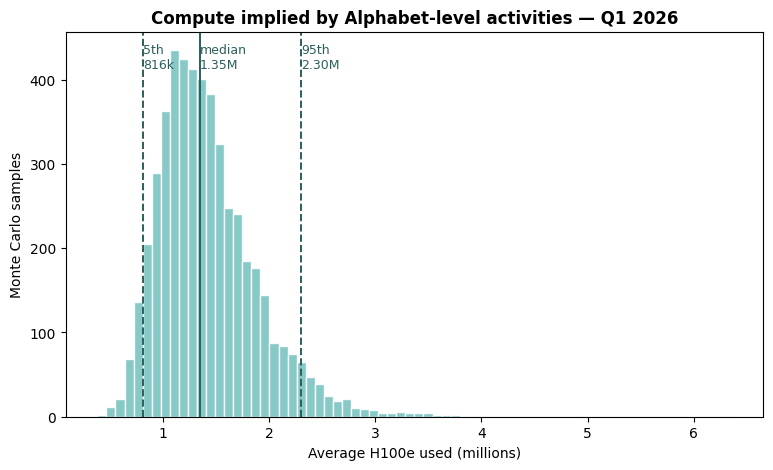

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(h100e_q1_2026 / 1e6, bins=70, color="#7AC4C0", alpha=0.9,
        edgecolor="white")
for q, style, lbl in [(5, "--", "5th"), (50, "-", "median"), (95, "--", "95th")]:
    v = p_q1[q] / 1e6
    ax.axvline(v, color="#2B5F5C", ls=style, lw=1.4)
    ax.text(v, ax.get_ylim()[1] * 0.97, f"{lbl}\n{fmt(p_q1[q])}", rotation=0,
            va="top", ha="left", fontsize=9, color="#2B5F5C")
ax.set_xlabel("Average H100e used (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("Compute implied by Alphabet-level activities — Q1 2026",
             weight="bold")
plt.show()

## The two uncertainties, visualized

Because the estimate is essentially `constant × compute_share ÷ cost_per_hour`,
the whole picture is a 2-D surface over the two sampled inputs. The heatmap
shows the median H100e at each combination; the dashed lines mark each input's
90% CI. The estimate is far more sensitive to the internal-cost assumption than
to the compute share.

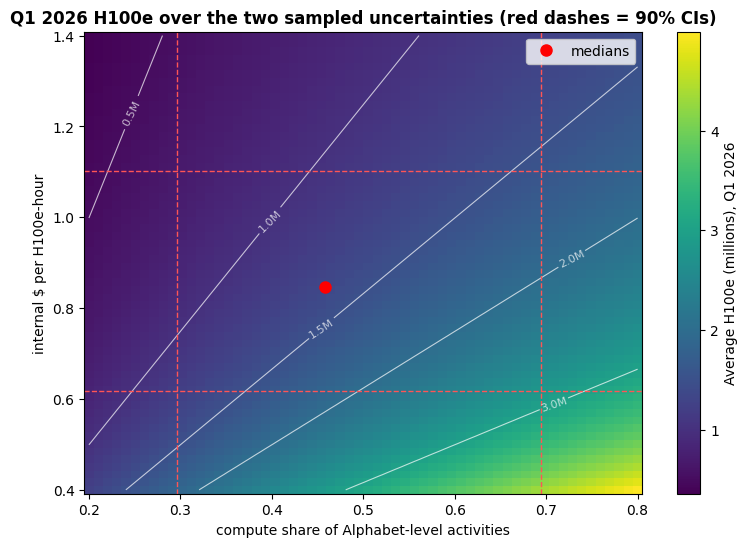

In [8]:
share_grid = np.linspace(0.20, 0.80, 60)
cost_grid = np.linspace(0.40, 1.40, 60)
S, C = np.meshgrid(share_grid, cost_grid)
grid_h100e = (spend_q1_2026 * S / C / hours_q1_2026) / 1e6  # millions

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(share_grid, cost_grid, grid_h100e, cmap="viridis",
                   shading="auto")
cs = ax.contour(share_grid, cost_grid, grid_h100e, levels=[0.5, 1, 1.5, 2, 3],
                colors="white", linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt=lambda v: f"{v:.1f}M", fontsize=8)
# 90% CI boxes for each input
for v in (compute_share_samples,):
    lo, hi = np.percentile(v, [5, 95])
    ax.axvline(lo, color="#ff5555", ls="--", lw=1); ax.axvline(hi, color="#ff5555", ls="--", lw=1)
for v in (cost_samples,):
    lo, hi = np.percentile(v, [5, 95])
    ax.axhline(lo, color="#ff5555", ls="--", lw=1); ax.axhline(hi, color="#ff5555", ls="--", lw=1)
ax.plot(np.median(compute_share_samples), np.median(cost_samples), "o",
        color="red", ms=8, label="medians")
fig.colorbar(im, ax=ax, label="Average H100e (millions), Q1 2026")
ax.set_xlabel("compute share of Alphabet-level activities")
ax.set_ylabel("internal $ per H100e-hour")
ax.set_title("Q1 2026 H100e over the two sampled uncertainties (red dashes = 90% CIs)",
             weight="bold")
ax.legend(loc="upper right")
plt.show()

## Sanity checks & caveats

- **Consistency with the DeepMind top-down model.** The separate DeepMind model
  (allocating Google's *installed* fleet) puts DeepMind at roughly **1.5–2M
  H100e** including inference. This spending model — R&D/training only, and an
  *upper bound* since it assumes all compute-dollars are DeepMind's — lands in a
  similar range at its median. That's reassuring, but also a tension: an
  R&D-only *upper bound* shouldn't sit *above* the all-in top-down estimate. If
  it does, that argues the true internal cost is toward the higher end of our
  range (or the compute share toward the lower end).
- **Upper-bound framing.** This attributes the entire compute portion of the
  bucket to DeepMind R&D. In reality some may be non-frontier, and conversely
  some DeepMind R&D (e.g. product-specific post-training for Search) may be
  booked in a business segment and *missed* here. These roughly offset but the
  net sign is unknown.
- **No inference.** Product/API inference is in the business segments, so this
  is strictly a training/research figure — not comparable to a lab's *total*
  fleet.
- **Cost basis, not price.** The output is not comparable to OpenAI's/Anthropic's
  cloud spend converted at market GPU-hour rates; multiply the internal cost by
  ~1.3–1.5× to get a market-equivalent, which would *lower* the H100e count.

In [9]:
print("Summary — average H100e used for Alphabet-level activities\n")
for label, p in [("Q1 2026", p_q1), ("FY 2025 (annual avg)", p_fy)]:
    print(f"{label}")
    print(f"  90% CI : {fmt(p[5])} – {fmt(p[95])}")
    print(f"  median : {fmt(p[50])}")
    print()

Summary — average H100e used for Alphabet-level activities

Q1 2026
  90% CI : 816k – 2.30M
  median : 1.35M

FY 2025 (annual avg)
  90% CI : 626k – 1.77M
  median : 1.04M

